In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/European_Ski_Resorts.csv")

df.head()

,Unnamed: 0,Resort,Country,HighestPoint,LowestPoint,DayPassPriceAdult,BeginnerSlope,IntermediateSlope,DifficultSlope,TotalSlope,Snowparks,NightSki,SurfaceLifts,ChairLifts,GondolaLifts,TotalLifts,LiftCapacity,SnowCannons
0,1,Alpendorf (Ski amedé),Austria,1980,740,52,30,81,4,115,Yes,No,22,16,11,49,75398,600
1,2,Soldeu-Pas de la Casa/​Grau Roig/​El Tarter/​C...,Andorra,2640,1710,47,100,77,33,210,Yes,Yes,37,28,7,72,99017,1032
2,3,Oberau (Wildschönau),Austria,1130,900,30,1,0,1,2,No,No,2,0,0,2,1932,0
3,4,Dachstein West,Austria,1620,780,42,15,33,3,51,Yes,Yes,25,8,3,36,32938,163
4,5,Rosa Khutor,Southern Russia,2320,940,22,30,26,21,77,Yes,No,6,11,10,27,49228,450


In [4]:
# Remove unnecessary index column
df = df.drop(columns=["Unnamed: 0"])

# Remove Russian ski resorts from the scope of this project
df = df[~df["Country"].isin(["Siberia", "Southern Russia"])].copy()

print("Shape after cleaning:", df.shape)
print("\nCountries:")
print(sorted(df["Country"].unique()))

Shape after cleaning: (371, 17)

Countries:
['Andorra', 'Austria', 'Bosnia and Herzegovina', 'Bulgaria', 'Czech Republic', 'Denmark', 'Finland', 'France', 'Germany', 'Greece', 'Italy', 'Liechtenstein', 'Lithuania', 'Netherlands', 'Norway', 'Poland', 'Romania', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Ukraine', 'United Kingdom']


In [5]:
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicated rows:")
print(df.duplicated().sum())

Shape: (371, 17)

Missing values:
Resort               0
Country              0
HighestPoint         0
LowestPoint          0
DayPassPriceAdult    0
BeginnerSlope        0
IntermediateSlope    0
DifficultSlope       0
TotalSlope           0
Snowparks            0
NightSki             0
SurfaceLifts         0
ChairLifts           0
GondolaLifts         0
TotalLifts           0
LiftCapacity         0
SnowCannons          0
dtype: int64

Duplicated rows:
0


In [6]:
print(sorted(df["Country"].unique()))

['Andorra', 'Austria', 'Bosnia and Herzegovina', 'Bulgaria', 'Czech Republic', 'Denmark', 'Finland', 'France', 'Germany', 'Greece', 'Italy', 'Liechtenstein', 'Lithuania', 'Netherlands', 'Norway', 'Poland', 'Romania', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Ukraine', 'United Kingdom']


In [7]:
selected_countries = [
    "Austria",
    "France",
    "Italy",
    "Switzerland",
    "Sweden",
    "Norway",
    "Finland",
    "Andorra",
    "Spain",
    "Germany"
]

df = df[df["Country"].isin(selected_countries)].copy()

print("Shape after country filter:", df.shape)
print("\nCountries included:")
print(sorted(df["Country"].unique()))

Shape after country filter: (333, 17)

Countries included:
['Andorra', 'Austria', 'Finland', 'France', 'Germany', 'Italy', 'Norway', 'Spain', 'Sweden', 'Switzerland']


In [8]:
print("Number of ski resorts:", len(df))

print("\nSki resorts per country:")
print(df["Country"].value_counts())

Number of ski resorts: 333

Ski resorts per country:
Country
Austria        89
France         83
Switzerland    61
Italy          44
Germany        24
Norway         10
Spain           8
Sweden          6
Andorra         5
Finland         3
Name: count, dtype: int64


In [9]:
df.describe()

,HighestPoint,LowestPoint,DayPassPriceAdult,BeginnerSlope,IntermediateSlope,DifficultSlope,TotalSlope,SurfaceLifts,ChairLifts,GondolaLifts,TotalLifts,LiftCapacity,SnowCannons
count,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000
mean,2160.039039,1107.900901,42.819820,39.324324,42.177177,12.936937,94.687688,14.570571,10.084084,4.282282,28.936937,37395.435435,238.561562
std,706.024797,389.372532,10.990027,56.072698,51.499870,18.538277,118.078409,14.959140,13.141222,6.860368,32.319735,48029.231332,425.871353
min,122.000000,90.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,1678.000000,820.000000,36.000000,10.000000,12.000000,2.000000,30.000000,5.000000,3.000000,0.000000,11.000000,11865.000000,0.000000
50%,2205.000000,1100.000000,44.000000,20.000000,25.000000,7.000000,51.000000,10.000000,5.000000,2.000000,18.000000,19956.000000,70.000000
75%,2640.000000,1372.000000,50.000000,45.000000,49.000000,15.000000,110.000000,18.000000,12.000000,5.000000,31.000000,39750.000000,280.000000
max,3899.000000,2180.000000,81.000000,312.000000,239.000000,103.000000,600.000000,89.000000,74.000000,40.000000,174.000000,252280.000000,2383.000000


In [10]:
print("Resorts with day pass price = 0:")
print(df[df["DayPassPriceAdult"] == 0][["Resort", "Country", "DayPassPriceAdult"]])

print("\nNumber of zero prices:")
print((df["DayPassPriceAdult"] == 0).sum())

Resorts with day pass price = 0:
        Resort Country  DayPassPriceAdult
123  Pragelato   Italy                  0
255    Puigmal  France                  0

Number of zero prices:
2


In [11]:
df = df[df["DayPassPriceAdult"] > 0].copy()

print("Shape after removing zero prices:", df.shape)
print("Minimum day pass price:", df["DayPassPriceAdult"].min())

Shape after removing zero prices: (331, 17)
Minimum day pass price: 17


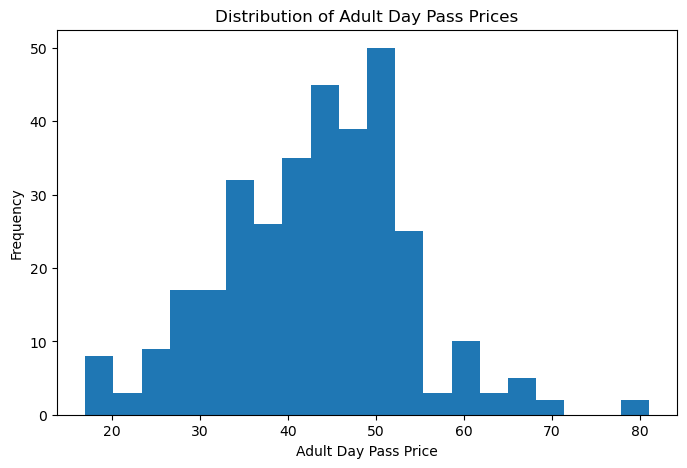

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(df["DayPassPriceAdult"], bins=20)

plt.xlabel("Adult Day Pass Price")
plt.ylabel("Frequency")
plt.title("Distribution of Adult Day Pass Prices")

plt.show()

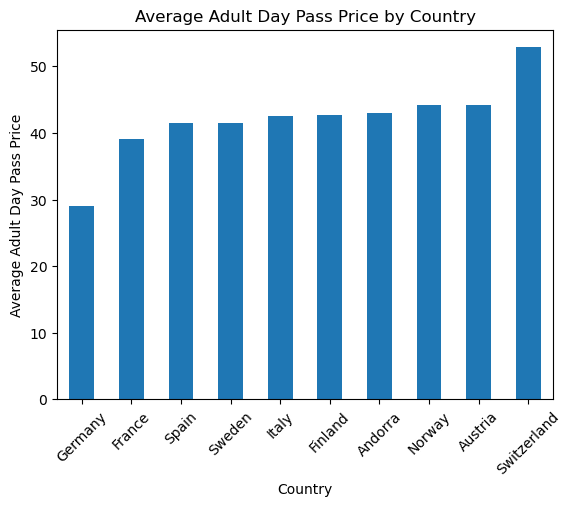

In [13]:
country_price = (
    df.groupby("Country")["DayPassPriceAdult"]
    .mean()
    .sort_values()
)

country_price.plot(kind="bar")

plt.ylabel("Average Adult Day Pass Price")
plt.title("Average Adult Day Pass Price by Country")
plt.xticks(rotation=45)

plt.show()

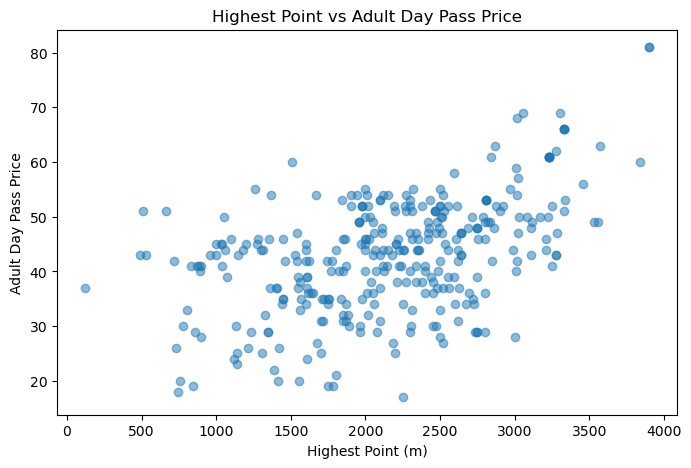

In [14]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["HighestPoint"],
    df["DayPassPriceAdult"],
    alpha=0.5
)

plt.xlabel("Highest Point (m)")
plt.ylabel("Adult Day Pass Price")
plt.title("Highest Point vs Adult Day Pass Price")

plt.show()

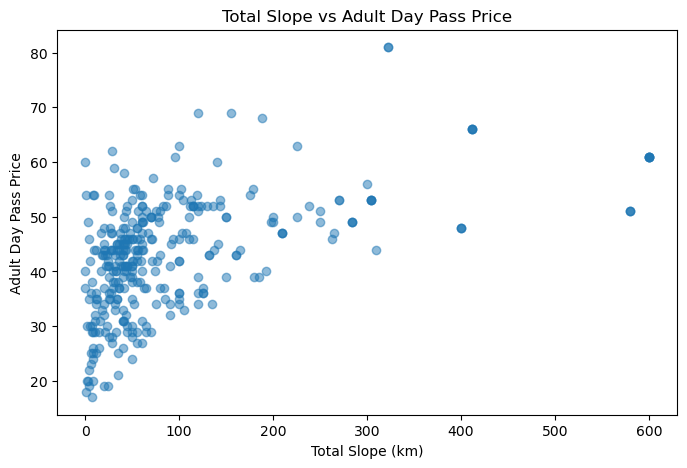

In [15]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["TotalSlope"],
    df["DayPassPriceAdult"],
    alpha=0.5
)

plt.xlabel("Total Slope (km)")
plt.ylabel("Adult Day Pass Price")
plt.title("Total Slope vs Adult Day Pass Price")

plt.show()

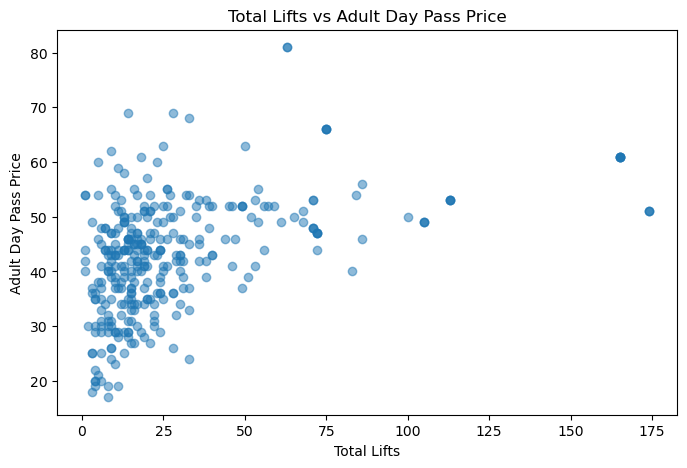

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["TotalLifts"],
    df["DayPassPriceAdult"],
    alpha=0.5
)

plt.xlabel("Total Lifts")
plt.ylabel("Adult Day Pass Price")
plt.title("Total Lifts vs Adult Day Pass Price")

plt.show()

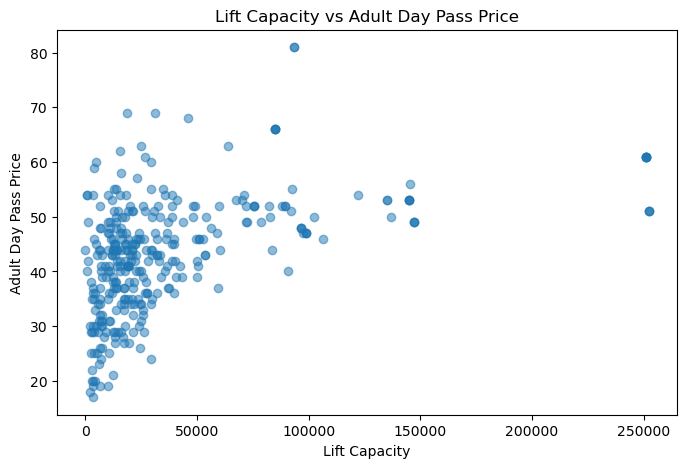

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["LiftCapacity"],
    df["DayPassPriceAdult"],
    alpha=0.5
)

plt.xlabel("Lift Capacity")
plt.ylabel("Adult Day Pass Price")
plt.title("Lift Capacity vs Adult Day Pass Price")

plt.show()

In [18]:
numeric_df = df.select_dtypes(include=[np.number])

correlations = numeric_df.corr()

print(
    correlations["DayPassPriceAdult"]
    .sort_values(ascending=False)
)

DayPassPriceAdult    1.000000
GondolaLifts         0.584622
IntermediateSlope    0.556486
TotalSlope           0.519240
DifficultSlope       0.497655
HighestPoint         0.497187
LiftCapacity         0.477200
TotalLifts           0.460434
ChairLifts           0.429968
BeginnerSlope        0.418529
SnowCannons          0.397960
SurfaceLifts         0.348863
LowestPoint          0.021295
Name: DayPassPriceAdult, dtype: float64


In [19]:
print(df.dtypes)

Resort                 str
Country                str
HighestPoint         int64
LowestPoint          int64
DayPassPriceAdult    int64
BeginnerSlope        int64
IntermediateSlope    int64
DifficultSlope       int64
TotalSlope           int64
Snowparks              str
NightSki               str
SurfaceLifts         int64
ChairLifts           int64
GondolaLifts         int64
TotalLifts           int64
LiftCapacity         int64
SnowCannons          int64
dtype: object


In [20]:
print("Snowparks values:")
print(df["Snowparks"].value_counts())

print("\nNightSki values:")
print(df["NightSki"].value_counts())

Snowparks values:
Snowparks
Yes    260
No      71
Name: count, dtype: int64

NightSki values:
NightSki
No     198
Yes    133
Name: count, dtype: int64


In [21]:
X = df.drop(columns=["Resort", "DayPassPriceAdult"])
y = df["DayPassPriceAdult"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Country', 'HighestPoint', 'LowestPoint', 'BeginnerSlope', 'IntermediateSlope', 'DifficultSlope', 'TotalSlope', 'Snowparks', 'NightSki', 'SurfaceLifts', 'ChairLifts', 'GondolaLifts', 'TotalLifts', 'LiftCapacity', 'SnowCannons']

Target:
DayPassPriceAdult


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 264
Test rows: 67


In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

categorical_features = ["Country", "Snowparks", "NightSki"]

numeric_features = [
    "HighestPoint",
    "LowestPoint",
    "BeginnerSlope",
    "IntermediateSlope",
    "DifficultSlope",
    "TotalSlope",
    "SurfaceLifts",
    "ChairLifts",
    "GondolaLifts",
    "TotalLifts",
    "LiftCapacity",
    "SnowCannons"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [24]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyRegressor(strategy="mean"))
    ]
)

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))
baseline_r2 = r2_score(y_test, baseline_predictions)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²:", baseline_r2)

Baseline MAE: 8.42995251017639
Baseline RMSE: 11.278391206972792
Baseline R²: -0.0028737943574042024


In [25]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]
)

ridge_model.fit(X_train, y_train)

ridge_predictions = ridge_model.predict(X_test)

ridge_mae = mean_absolute_error(y_test, ridge_predictions)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_predictions))
ridge_r2 = r2_score(y_test, ridge_predictions)

print("Ridge MAE:", ridge_mae)
print("Ridge RMSE:", ridge_rmse)
print("Ridge R²:", ridge_r2)

Ridge MAE: 3.6037793916675565
Ridge RMSE: 4.6694635948829895
Ridge R²: 0.8280960082567596


In [26]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest MAE: 2.9333582089552235
Random Forest RMSE: 4.095011025443944
Random Forest R²: 0.8677906638255347


In [27]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                random_state=42
            )
        )
    ]
)

gb_model.fit(X_train, y_train)

gb_predictions = gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_predictions)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))
gb_r2 = r2_score(y_test, gb_predictions)

print("Gradient Boosting MAE:", gb_mae)
print("Gradient Boosting RMSE:", gb_rmse)
print("Gradient Boosting R²:", gb_r2)

Gradient Boosting MAE: 2.6519062410590046
Gradient Boosting RMSE: 3.738539255732336
Gradient Boosting R²: 0.8898065287201392


In [28]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Ridge Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        baseline_mae,
        ridge_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        baseline_rmse,
        ridge_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R²": [
        baseline_r2,
        ridge_r2,
        rf_r2,
        gb_r2
    ]
})

results.sort_values("MAE")

,Model,MAE,RMSE,R²
3,Gradient Boosting,2.651906,3.738539,0.889807
2,Random Forest,2.933358,4.095011,0.867791
1,Ridge Regression,3.603779,4.669464,0.828096
0,Baseline,8.429953,11.278391,-0.002874


In [29]:
feature_names = gb_model.named_steps["preprocessor"].get_feature_names_out()

importances = gb_model.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
22,num__GondolaLifts,0.386296
9,cat__Country_Switzerland,0.142896
24,num__LiftCapacity,0.094986
14,num__HighestPoint,0.075012
3,cat__Country_France,0.056744
17,num__IntermediateSlope,0.055258
19,num__TotalSlope,0.042555
4,cat__Country_Germany,0.032353
15,num__LowestPoint,0.017227
21,num__ChairLifts,0.016738


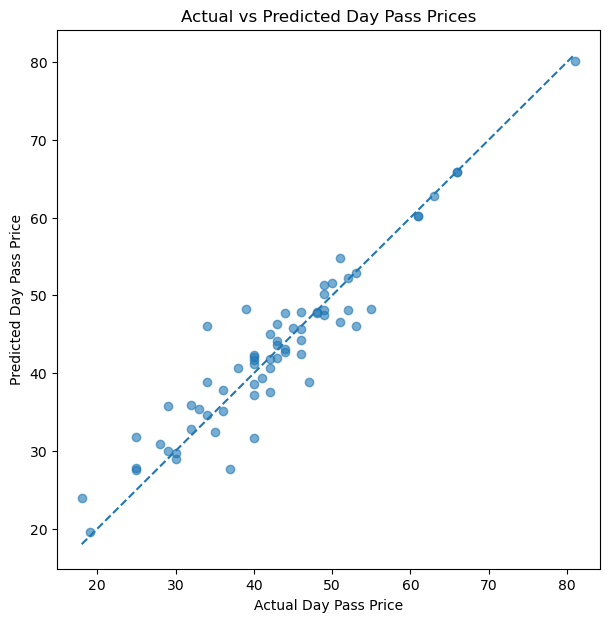

In [30]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    gb_predictions,
    alpha=0.6
)

plt.xlabel("Actual Day Pass Price")
plt.ylabel("Predicted Day Pass Price")
plt.title("Actual vs Predicted Day Pass Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

In [31]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    gb_model,
    "../models/ski_pass_price_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [32]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicated rows:")
print(df.duplicated().sum())

Missing values:
Resort               0
Country              0
HighestPoint         0
LowestPoint          0
DayPassPriceAdult    0
BeginnerSlope        0
IntermediateSlope    0
DifficultSlope       0
TotalSlope           0
Snowparks            0
NightSki             0
SurfaceLifts         0
ChairLifts           0
GondolaLifts         0
TotalLifts           0
LiftCapacity         0
SnowCannons          0
dtype: int64

Duplicated rows:
0


### Data quality check

The dataset was checked for missing values and duplicated rows.

- No missing values were found.
- No duplicated rows were found.

Therefore, no imputation or duplicate removal was necessary.

In [33]:
from sklearn.preprocessing import StandardScaler

ridge_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

ridge_scaled_model = Pipeline(
    steps=[
        ("preprocessor", ridge_preprocessor),
        ("model", Ridge(alpha=1.0))
    ]
)

ridge_scaled_model.fit(X_train, y_train)

ridge_scaled_predictions = ridge_scaled_model.predict(X_test)

ridge_scaled_mae = mean_absolute_error(
    y_test,
    ridge_scaled_predictions
)

ridge_scaled_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_scaled_predictions
    )
)

ridge_scaled_r2 = r2_score(
    y_test,
    ridge_scaled_predictions
)

print("Scaled Ridge MAE:", ridge_scaled_mae)
print("Scaled Ridge RMSE:", ridge_scaled_rmse)
print("Scaled Ridge R²:", ridge_scaled_r2)

Scaled Ridge MAE: 3.627184432677535
Scaled Ridge RMSE: 4.688434786273805
Scaled Ridge R²: 0.8266963406742426


In [34]:
from sklearn.model_selection import cross_val_score

models_for_cv = {
    "Scaled Ridge": ridge_scaled_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

for name, model in models_for_cv.items():
    cv_scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="neg_mean_absolute_error"
    )

    mae_scores = -cv_scores

    print(name)
    print("CV MAE scores:", mae_scores)
    print("Mean CV MAE:", mae_scores.mean())
    print("Std CV MAE:", mae_scores.std())
    print()

Scaled Ridge
CV MAE scores: [3.56977187 4.90872458 4.75270761 4.85173423 5.44077826]
Mean CV MAE: 4.704743310576466
Std CV MAE: 0.6156984448131614

Random Forest
CV MAE scores: [3.76149254 3.65886364 4.22863636 5.01606061 3.90969697]
Mean CV MAE: 4.1149500226142015
Std CV MAE: 0.48989808513694205

Gradient Boosting
CV MAE scores: [3.67046466 3.74093562 4.15494413 4.81955337 3.71028691]
Mean CV MAE: 4.019236937156439
Std CV MAE: 0.43668448026044265



### Cross-validation results

To evaluate the models more reliably, 5-fold cross-validation was performed using Mean Absolute Error (MAE).

The average cross-validation MAE was approximately:

- Scaled Ridge Regression: 4.70
- Random Forest: 4.11
- Gradient Boosting: 4.02

Gradient Boosting achieved the lowest average MAE and also had the lowest variation between the folds. This supports the earlier test-set results and indicates that Gradient Boosting is the strongest and most consistent model among the tested algorithms.

In [35]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_features = [
    "HighestPoint",
    "TotalSlope",
    "TotalLifts",
    "LiftCapacity",
    "SnowCannons",
    "DayPassPriceAdult"
]

cluster_data = df[cluster_features].copy()

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(cluster_scaled)

print("Number of resorts in each cluster:")
print(df["Cluster"].value_counts().sort_index())

print("\nAverage values per cluster:")
print(
    df.groupby("Cluster")[cluster_features]
    .mean()
    .round(2)
)

Number of resorts in each cluster:
Cluster
0    262
1      9
2     60
Name: count, dtype: int64

Average values per cluster:
         HighestPoint  TotalSlope  TotalLifts  LiftCapacity  SnowCannons  \
Cluster                                                                    
0             1990.76       48.87       16.58      18811.67        98.18   
1             2975.33      593.33      168.00     251333.33      1946.67   
2             2758.93      221.77       62.70      87441.63       603.32   

         DayPassPriceAdult  
Cluster                     
0                    40.23  
1                    57.67  
2                    53.33  


c:\Users\gabri\anaconda3\envs\AIkurs-statistik\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


### Unsupervised learning - K-Means clustering

K-Means clustering was used to explore whether the ski resorts could be grouped based on similar characteristics without using predefined labels.

Three clusters were identified:

- **Cluster 0:** Mostly smaller ski resorts with fewer slopes, lifts and lower lift capacity. These resorts also had the lowest average day pass price.
- **Cluster 2:** Larger ski resorts with more slopes, lifts, snow cannons and higher lift capacity. Their average day pass price was also higher.
- **Cluster 1:** A small group of very large ski resorts with substantially more slopes, lifts, lift capacity and snow cannons than the other clusters. These resorts had the highest average day pass price.

The clustering suggests that resort size and infrastructure are related to the adult day pass price and provides an additional way to understand the structure of the dataset.

In [36]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV MAE:")
print(-grid_search.best_score_)

Best parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best CV MAE:
4.010625367934695


In [37]:
best_gb_model = grid_search.best_estimator_

tuned_predictions = best_gb_model.predict(X_test)

tuned_mae = mean_absolute_error(
    y_test,
    tuned_predictions
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_predictions
    )
)

tuned_r2 = r2_score(
    y_test,
    tuned_predictions
)

print("Tuned Gradient Boosting MAE:", tuned_mae)
print("Tuned Gradient Boosting RMSE:", tuned_rmse)
print("Tuned Gradient Boosting R²:", tuned_r2)

Tuned Gradient Boosting MAE: 2.6519062410590046
Tuned Gradient Boosting RMSE: 3.738539255732336
Tuned Gradient Boosting R²: 0.8898065287201392


### Hyperparameter tuning

GridSearchCV was used to test different hyperparameter combinations for the Gradient Boosting model.

The best parameters were:

- Learning rate: 0.1
- Max depth: 3
- Minimum samples split: 2
- Number of estimators: 100

The tuned model achieved approximately:

- MAE: 2.65
- RMSE: 3.74
- R²: 0.89

The tuned model produced essentially the same performance as the original Gradient Boosting model. This confirms that the original model configuration was already well suited to this dataset.

In [38]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_gb_model,
    "../models/ski_pass_price_model.pkl"
)

print("Final model saved successfully.")

Final model saved successfully.


## Final conclusion

The goal of this project was to predict the adult day pass price of European ski resorts based on resort characteristics such as elevation, slope length, lift infrastructure, snow cannons and country.

Several regression models were evaluated:

- Dummy Regressor as a baseline
- Ridge Regression
- Random Forest Regressor
- Gradient Boosting Regressor

Gradient Boosting achieved the best performance on the test set with approximately:

- MAE: 2.65
- RMSE: 3.74
- R²: 0.89

5-fold cross-validation also showed that Gradient Boosting had the lowest average MAE among the tested models.

Hyperparameter tuning with GridSearchCV confirmed that the original Gradient Boosting configuration was already well suited to the dataset.

K-Means clustering was also used as an unsupervised learning method. The clustering identified groups of smaller, larger and very large ski resorts based on their infrastructure and characteristics.

The final Gradient Boosting pipeline includes the preprocessing steps and the trained model, and it was saved as:

`ski_pass_price_model.pkl`

This model is used by the Ski Trip Planner web application to generate day pass price predictions from user input.